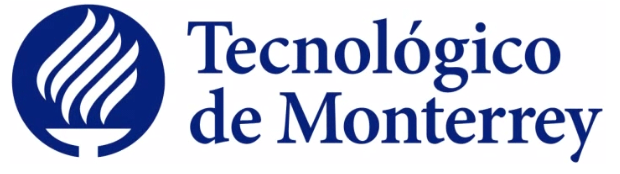

Tecnológico de Monterrey - Campus Santa Fe

**Curso:** Inteligencia artificial avanzada para la ciencia de datos II (Gpo 101)

**Alumno:** Pedro Mauri Mtz - A01029143

**Profesor:** Esteban Castillo Juarez

In [8]:
"""
Pedro Mauri Mtz - A01029143
Examen Final del módulo de NLP
"""

'\nPedro Mauri Mtz - A01029143\nExamen Final del módulo de NLP\n'

## Imports Generales

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

from collections import Counter
import re
import unicodedata
import emoji

# NLTK
import nltk
# Recursos nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_treebank_tagger', quiet = True)
nltk.download('sentiwordnet')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
# Funciones nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.corpus import sentiwordnet as swn

# Gensim
import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

# Scikit-Learn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

from scipy.sparse import hstack, csr_matrix

# PyTorch y transformers
import torch
from transformers import AutoTokenizer, AutoModel

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pedro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\pedro\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Error loading averaged_perceptron_treebank_tagger: Package
[nltk_data]     'averaged_perceptron_treebank_tagger' not found in
[nltk_data]     index
[nltk_data] Downloading package sentiwordnet to
[nltk_data]     C:\Users\pedro\AppData\Roaming\nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pedro\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\pedro\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already u

# Tarea 1: Uso de técnicas de PLN para preprocesamiento de textos

In [10]:
"""
Pedro Mauri Mtz - A01029143
Tarea 1: Uso de técnicas de PLN para preprocesamiento de textos
"""

'\nPedro Mauri Mtz - A01029143\nTarea 1: Uso de técnicas de PLN para preprocesamiento de textos\n'

### Leer archivos .txt de datos de entrenamiento y de testeo.

Path / Nombres de los archivos

In [11]:
train_path = Path(ROOT + "/Datasets/originalTraining-1.txt") # Training
test_path  = Path(ROOT + "/Datasets/originalTest-1.txt") # Testing

# Formato del los archivos .txt:
#     id \t user_id \t label \t text

Función que lee el archivo, separa datos en:
- id.
- user_id.
- label.
- text.

Y los guarda en un dataframe de Pandas.

In [12]:
def load_twitter_file(path):
    rows = []

    with path.open(encoding = "utf-8") as file:
        for line in file:

            line = line.strip()

            if not line:
                continue

            # Separar en tabs.
            parts = line.split("\t")

            if len(parts) < 4:
                continue

            # Guardar partes en su respectiva variable.
            tweet_id, user_id, label, text = parts[0], parts[1], parts[2], "\t".join(parts[3:])

            rows.append({"tweet_id": tweet_id,
                         "user_id": user_id,
                         "label": label,
                         "text": text})

    return pd.DataFrame(rows)

Llamar función para crear dataframe de entrenamiento y de testeo.

In [13]:
df_train = load_twitter_file(train_path)
df_test  = load_twitter_file(test_path)

Primeras 5 muestras de entrenamiento.

In [14]:
# df_train.head()

Primeras 5 muestras de testeo.

In [15]:
# df_test.head()

Para imprimir todos los datos en el Dataframe de entrenamiento.

In [16]:
"""
# Configurar para mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Configurar para mostrar todas las filas
pd.set_option('display.max_rows', None)

# Opcional: para ajustar el ancho de las columnas si es necesario
pd.set_option('display.max_colwidth', None)

df_train
"""

"\n# Configurar para mostrar todas las columnas\npd.set_option('display.max_columns', None)\n\n# Configurar para mostrar todas las filas\npd.set_option('display.max_rows', None)\n\n# Opcional: para ajustar el ancho de las columnas si es necesario\npd.set_option('display.max_colwidth', None)\n\ndf_train\n"

### 1. Pipeline de datos para vocabulario.

#### **Codificación / Decodificación:**

Convertir el texto a forma NFC. (Normalización Unicode)

#### **Manejo de mayúsculas y minúsculas:**

Tras realizar los diversos métodos para procesar el texto; todas las letras mayúsculas se convierten a minúsculas para brindar menor variación. Sin emabrgo, se genera una feature auxiliar del nivel de énfasis (Se cuentan el número de mayúsculas consecutivas en un token).

#### **Uso de patrones Regex:**

Cada vez que se encuentra uno de los siguientes patrones se sustituye por su respectivo token '<TOKEN>'.

- Al modelo no le interesa el nombre de la persona interesa o el nombre completo de la URL, solo le interesa el hecho que se mencionó a una persona o se escribió un URL.

  - URLs → `<URL>`
  - Menciones → `<USER>`

- Cuando se encuentra el patrón de un hashtag, se sustituye el simbolo # por el token de hashtag, se separan las palabras ubicadas justo después de '#', que no tengan espacios entre si por mayusculas o guiones, si se toman en cuenta como tokens.

  - Hashtags → `<HASHTAG>` + - Palabras del hashtag.

- Por otro lado, para los signos de interrogación y exclamación consecutivos (!!! / ???), se cuentan cuantos simbolos hay para featurizarlo, y se sustutuyen con solo un símbolo para la tokenización.

  - (!!! / ???)  → Tokenizar solo uno y contar cuantos simbolos consecutivos hay.

#### **Caso de Emoji:**

Para los emojis se definió un diccionario donde se especifica con una palabra el significado emocial representado a ese emoji.

  - Emojis → Tokenizar y mapear a sentimiento base.

#### **Caso de Contracción:**

Para las contracciones, tambien se definió un diccionario donde se especifica la palabra completa de la respectiva contracción.

  - Contracción → Tokenizar palabra completa encontrada en el diccionario.

#### **Manejo de palabras cerradas:**

Lo que se realiza es lo siguiente; en un diccionario se definió una corta lista de stopwords que tienen una carga muy baja de valor sentimental. Con el objetivo de omitir estas palabras en la tokenización.

#### **Manejo de signos de puntuación:**

Como ya se mencionó, se utilizan patrones de Regex para normalizar signos de exclamación y de interrogación repetivos consecutivos. Mientras que el resto de caracteres que no sean  números, guion bajo, letras o '<>', ([^\w<>]+), se omiten.

#### **Manejo de etiquetas del discurso (PoS Tags):**

Al usar lematización, se debe utilizar PoS para diseñar un vocabulario más limpio tomando en cuenta la gramática.

- **Tokenización:** Usando `nltk.word_tokenize`.

- **Etiquetado morfosintáctico (PoS Tagging):** Mejorar la lematización.

- **Lematización:** `WordNetLemmatizer` Usando el PoS detectado.

- **Normalización de repetición de caracteres:** `soooo` → `soo`.

- **Salida:** Lista de tokens limpios + lista de features auxiliares (mayúsculas, exclamaciones, presencia de emoji).


Normalización de Unicode.

In [17]:
import unicodedata

def normalize_unicode(text: str) -> str:
    text = unicodedata.normalize("NFC", text)

    return text

Uso de patrones Regex.

In [18]:
# URLs:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
# Menciones de usuarios:
USER_RE = re.compile(r"@\w+")
# Hashtags:
HASHTAG_RE = re.compile(r"#\w+")
# Multiples signos de exclamación y de interrogación
MULTI_EXCL = re.compile(r"!+")
MULTI_QUES = re.compile(r"\?+")

Separador de palabras dentro de un hashtag.

In [19]:
def split_hashtag(tag: str):
    # #HappyFriday -> ['happy', 'friday']
    tag = tag.lstrip("#")
    # Separar por mayúsculas o guiones
    parts = re.sub(r"([A-Z])", r" \1", tag).split()

    return [p.lower() for p in parts if p]

Diccionario de Emojis.

In [20]:
EMOJI_SENTIMENT = {
    "😂": "joy",
    "🤣": "joy",
    "😅": "joy",
    "😊": "joy",
    "😍": "love",
    "😘": "love",
    "❤️": "love",
    "❤": "love",
    "💔": "sadness",
    "😢": "sadness",
    "😭": "sadness",
    "😡": "anger",
    "😠": "anger",
    "😤": "anger",
    "😱": "fear",
    "👍": "approval",
    "👎": "disapproval",
}

Lista de stopwords con poco peso sentimental.

In [21]:
BASIC_STOPWORDS = {
    "the","a","an","to","of","in","on","for","and","or"
}

Diccionario de contracciones.

In [22]:
CONTRACTIONS = {
    "'m":"am",
    "'ll":"will",
    "'s":"is",
    "'re":"are",
    "'ve":"have",
    "'d":"would"
}

PoS Tagging y lematización.

In [23]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


Implementación de SentiWordNet.

In [24]:
def swn_polarity(lemma, wn_pos):

    # convertir POS de wordnet a la letra que usa SentiWordNet
    pos_map = {
        wordnet.NOUN: 'n',
        wordnet.VERB: 'v',
        wordnet.ADJ: 'a',
        wordnet.ADV: 'r'
    }

    pos_char = pos_map.get(wn_pos, None)

    if pos_char is None:
        return None

    # obtener todos los synsets para ese lemma y pos
    synsets = list(swn.senti_synsets(lemma, pos_char))
    if not synsets:
        return None

    # estrategia simple: tomar el primero (más frecuente)
    s = synsets[0]
    pos_score = s.pos_score()
    neg_score = s.neg_score()

    if pos_score > neg_score and pos_score > 0:
        return "pos"
    elif neg_score > pos_score and neg_score > 0:
        return "neg"
    else:
        return "neu"

Procesamiento de texto completo y tokenización.

In [25]:
from nltk import word_tokenize, pos_tag

def preprocess_text(text: str):

    text = normalize_unicode(text)
    text = text.replace("&amp;", "&")

    # Patrones Regex:

    # URLs y menciones a usuarios
    text = URL_RE.sub(" __URL__ ", text)
    # text = USER_RE.sub(" __USER__ ", text)
    users = USER_RE.findall(text)

    # Detectar hashtags
    hashtags = HASHTAG_RE.findall(text)

    # Normalización de signos de exclamación y interrogación
    exclamations = len(MULTI_EXCL.findall(text))
    questions = len(MULTI_QUES.findall(text))
    text = MULTI_EXCL.sub(" ! ", text)
    text = MULTI_QUES.sub(" ? ", text)

    # Tokenizar
    tokens = word_tokenize(text)

    # Tokenizar contenido de Hashtag
    expanded_tokens = []
    for tok in tokens:

        if tok.startswith("#"): # Si se encuentra un hashtag:
            expanded_tokens.append("<HASHTAG>") # Tokenizar "<HASHTAG>" en vez de "#"
            expanded_tokens.extend(split_hashtag(tok)) # Procesar palabras del hashtag
        elif tok.startswith("@"):
            expanded_tokens.append("<USER>") # Tokenizar "<USER>" en vez de "@"
        elif tok == "__URL__": # Si se encuentra una mención:
            expanded_tokens.append("<URL>")
        else:
            expanded_tokens.append(tok.lower()) # Convertir todas las letras a minúsculas

    # Etiquetar token con PoS
    tagged = pos_tag(expanded_tokens)

    clean_tokens = []
    for word, tag in tagged:

        # Porcesar Emojis
        if word in emoji.EMOJI_DATA:
            sent = EMOJI_SENTIMENT.get(word, None)
            if sent:
                clean_tokens.append(sent)
            continue

        # Procesar Contracciones
        if word in CONTRACTIONS:
            sent = CONTRACTIONS.get(word, None)
            if sent:
                clean_tokens.append(sent)
            continue

        # Filtrar puntuación
        if re.fullmatch(r"[^\w<>]+", word):
            continue

        # Omitir Stop Words de la lista
        if word in BASIC_STOPWORDS:
            continue

        # Lematizar
        wn_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, wn_pos)
        clean_tokens.append(lemma)

        # Enriquecimiento con SentiWordNet
        pol = swn_polarity(lemma, wn_pos)
        if pol == "pos":
            clean_tokens.append("<SENT_POS>")
        elif pol == "neg":
            clean_tokens.append("<SENT_NEG>")

    # Guardar metadatos del texto (caracteristicas adicionales)
    meta = {
        "exclamations": exclamations,
        "questions": questions,
        "has_hashtag": len(hashtags) > 0
    }

    return clean_tokens, meta


#### Procesar texto de entrenamiento

Tokens limpios e información meta de la primera muestra en 'df_train'.

In [26]:
sample = df_train["text"].iloc[0]
preprocess_text(sample)

(['gas',
  'by',
  'my',
  'house',
  'hit',
  '3.39',
  'i',
  'am',
  'go',
  'chapel',
  'hill',
  'sat'],
 {'exclamations': 1, 'questions': 0, 'has_hashtag': False})

Pocesamiento de texto en los datos de entrenamiento y agregado de tokens limpios e información meta en su Dataframe.

In [27]:
df_train["clean_tokens"], df_train["meta"] = zip(*df_train["text"].apply(preprocess_text))

df_train.head()

,tweet_id,user_id,label,text,clean_tokens,meta
0,264183816548130816,15140428,positive,Gas by my house hit $3.39!!!! I'm going to Cha...,"[gas, by, my, house, hit, 3.39, i, am, go, cha...","{'exclamations': 1, 'questions': 0, 'has_hasht..."
1,264249301910310912,18516728,negative,Iranian general says Israel's Iron Dome can't ...,"[iranian, general, say, israel, is, iron, dome...","{'exclamations': 0, 'questions': 0, 'has_hasht..."
2,264105751826538497,147088367,positive,with J Davlar 11th. Main rivals are team Polan...,"[with, j, davlar, 11th, main, <SENT_POS>, riva...","{'exclamations': 0, 'questions': 0, 'has_hasht..."
3,264094586689953794,332474633,negative,"Talking about ACT's && SAT's, deciding where I...","[talk, about, act, is, sat, is, decide, where,...","{'exclamations': 0, 'questions': 0, 'has_hasht..."
4,254941790757601280,557103111,negative,"They may have a SuperBowl in Dallas, but Dalla...","[they, may, have, <SENT_POS>, superbowl, dalla...","{'exclamations': 0, 'questions': 0, 'has_hasht..."


Pocesamiento de texto en los datos de entrenamiento y agregado de tokens limpios e información meta en su Dataframe.

In [28]:
df_test["clean_tokens"], df_test["meta"] = zip(*df_test["text"].apply(preprocess_text))

df_test.head()

,tweet_id,user_id,label,text,clean_tokens,meta
0,260097528899452929,595739778,neutral,"Won the match #getin . Plus, tomorrow is a ver...","[win, <SENT_POS>, match, <HASHTAG>, getin, plu...","{'exclamations': 0, 'questions': 0, 'has_hasht..."
1,262968617233162240,757209662,positive,Lunch from my new Lil spot ...THE COTTON BOWL ...,"[lunch, from, my, new, <SENT_POS>, lil, spot, ...","{'exclamations': 0, 'questions': 0, 'has_hasht..."
2,263790847424880641,420538325,positive,SNC Halloween Pr. Pumped. Let's work it for Su...,"[snc, halloween, pr, pump, let, is, work, it, ...","{'exclamations': 0, 'questions': 0, 'has_hasht..."
3,264221473558917120,331180650,neutral,Manchester United will try to return to winnin...,"[manchester, unite, will, <SENT_POS>, try, ret...","{'exclamations': 0, 'questions': 0, 'has_hasht..."
4,264091690632105984,241608245,neutral,Going to a bulls game with Aaliyah & hope next...,"[go, bull, game, with, aaliyah, hope, <SENT_PO...","{'exclamations': 0, 'questions': 0, 'has_hasht..."


#### Construir Vocabulario

Enlistar todos los tokens de los textos de entrenamiento en una sola lista.

In [29]:
# Juntar todos los tokens de entrenamiento en una sola lista
all_train_tokens = [tok for toks in df_train["clean_tokens"] for tok in toks]
freq_train = Counter(all_train_tokens)

sorted_freq_train = sorted(freq_train.values(), reverse = True)
ranks_freq_train = range(1, len(sorted_freq_train) + 1)

# print(all_train_tokens)
print(freq_train)
# print(sorted_freq_train)

Counter({'<SENT_POS>': 12063, '<SENT_NEG>': 4936, 'be': 3104, '<HASHTAG>': 1882, 'i': 1869, '<USER>': 1708, '<URL>': 1700, 'is': 1298, 'at': 1265, 'it': 1170, 'with': 1090, 'tomorrow': 1037, 'you': 922, 'have': 893, 'go': 763, 'will': 718, 'day': 644, 'my': 612, 'night': 606, 'that': 603, 'this': 577, 'do': 548, 'get': 542, 'may': 492, 'just': 490, "n't": 489, 'tonight': 481, 'out': 463, 'see': 443, 'we': 412, 'time': 389, 'all': 381, 'today': 381, 'come': 375, 'friday': 369, 'saturday': 364, 'from': 359, 'game': 355, 'sunday': 348, 'up': 342, 'but': 338, 'so': 338, 'me': 332, 'watch': 323, 'he': 323, 'am': 318, '1st': 313, 'new': 301, 'if': 289, 'like': 286, 'good': 281, 'about': 280, 'make': 273, 'not': 270, 'one': 255, 'a': 255, 'monday': 241, 'thursday': 236, 'now': 235, 'say': 233, 'last': 231, 'u': 229, 'by': 225, 'play': 221, '2': 214, 'your': 206, '2nd': 202, 'what': 202, 'win': 201, 'his': 199, 'love': 198, 'show': 193, 'can': 188, 'look': 187, 'they': 184, 'start': 178, 'thin

Enlistar todos los tokens de los textos de testeo en una sola lista.

In [30]:
# Juntar todos los tokens de testeo en una sola lista
all_test_tokens = [tok for toks in df_test["clean_tokens"] for tok in toks]
freq_test = Counter(all_test_tokens)

sorted_freq_test = sorted(freq_test.values(), reverse = True)
ranks_freq_test = range(1, len(sorted_freq_test) + 1)

# print(all_test_tokens)
print(freq_test)
# print(sorted_freq_test)

Counter({'<SENT_POS>': 1936, '<SENT_NEG>': 902, 'be': 499, 'i': 351, '<HASHTAG>': 297, '<USER>': 273, '<URL>': 241, 'is': 219, 'it': 187, 'you': 182, 'tomorrow': 175, 'with': 169, 'at': 147, 'have': 144, 'go': 135, 'may': 120, 'my': 117, "n't": 108, 'that': 101, 'do': 100, 'get': 97, 'will': 92, 'game': 92, 'this': 87, 'day': 76, 'watch': 73, 'sunday': 72, 'see': 71, 'saturday': 70, 'he': 68, 'night': 63, 'but': 63, 'so': 63, 'just': 62, 'time': 58, 'all': 58, 'me': 58, 'u': 56, 'we': 56, 'friday': 55, 'not': 53, '1st': 51, 'come': 51, 'monday': 50, 'like': 48, 'new': 45, 'from': 44, '2nd': 44, 'love': 43, 'up': 43, 'make': 43, 'can': 43, 'about': 43, 'out': 42, 'am': 42, 'good': 41, 'if': 41, 'one': 40, 'what': 40, 'by': 39, 'wait': 38, 'play': 38, 'back': 37, 'when': 37, 'want': 37, '2': 37, 'ca': 37, 'win': 36, '3': 36, 'thursday': 35, 'na': 34, 'his': 34, 'some': 34, 'know': 33, 'now': 33, 'say': 33, 'last': 33, '4th': 33, '3rd': 32, 'there': 31, 'no': 31, 'who': 30, 'season': 30, 

### 2. Visualizaciones de vocabulario.

1.1 Ley de Zipf Entrenamiento

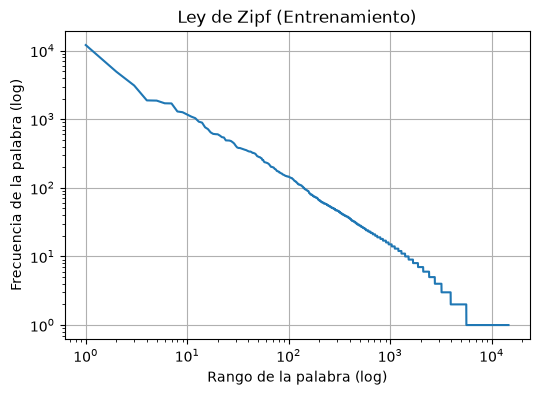

In [31]:
plt.figure(figsize = (6,4))
plt.loglog(ranks_freq_train, sorted_freq_train)
plt.title("Ley de Zipf (Entrenamiento)")
plt.xlabel("Rango de la palabra (log)")
plt.ylabel("Frecuencia de la palabra (log)")
plt.grid(True)
plt.show()

1.2 Ley de Zipf Testeo

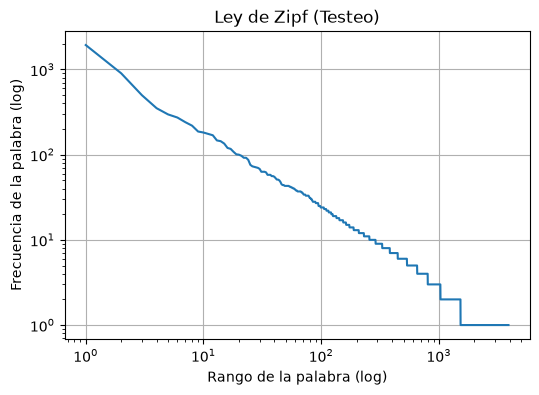

In [32]:
plt.figure(figsize = (6,4))
plt.loglog(ranks_freq_test, sorted_freq_test)
plt.title("Ley de Zipf (Testeo)")
plt.xlabel("Rango de la palabra (log)")
plt.ylabel("Frecuencia de la palabra (log)")
plt.grid(True)
plt.show()

2.1 Top de 30 tokens de entrenamiento.

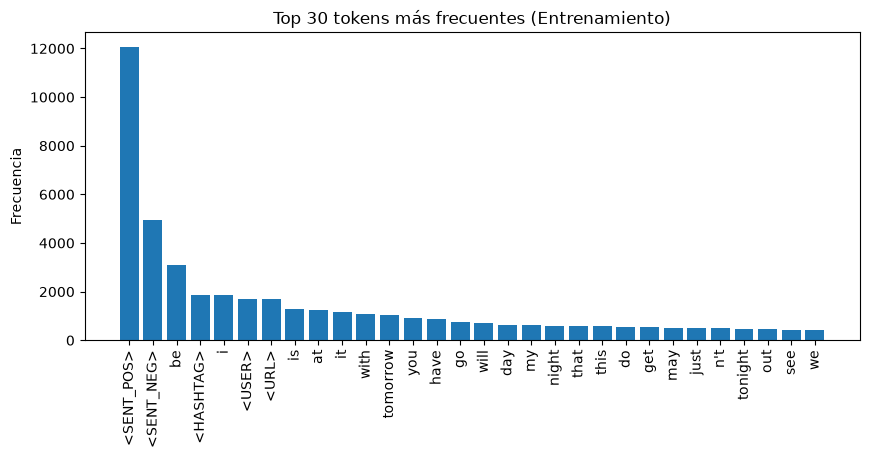

In [33]:
top_n = 30
tokens, counts = zip(*freq_train.most_common(top_n))

plt.figure(figsize = (10,4))
plt.bar(tokens, counts)
plt.xticks(rotation = 90)
plt.title("Top 30 tokens más frecuentes (Entrenamiento)")
plt.ylabel("Frecuencia")
plt.show()

2.1 Top de 30 tokens de testeo.

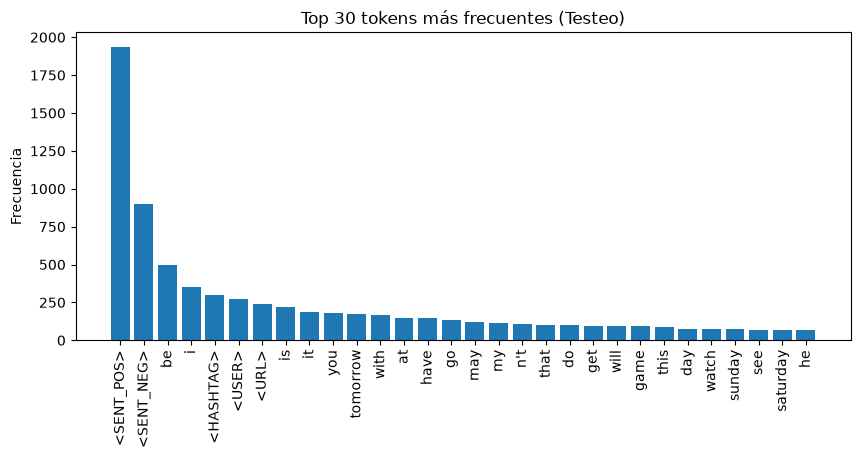

In [34]:
top_n = 30
tokens, counts = zip(*freq_test.most_common(top_n))

plt.figure(figsize = (10,4))
plt.bar(tokens, counts)
plt.xticks(rotation = 90)
plt.title("Top 30 tokens más frecuentes (Testeo)")
plt.ylabel("Frecuencia")
plt.show()

3.1 Distribución de cantidad de tokens por texto de entrenamiento.

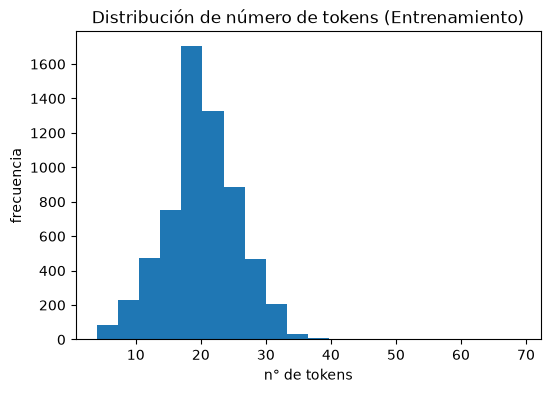

In [35]:
lengths = df_train["clean_tokens"].apply(len)

plt.figure(figsize = (6,4))
plt.hist(lengths, bins = 20)
plt.title("Distribución de número de tokens (Entrenamiento)")
plt.xlabel("n° de tokens")
plt.ylabel("frecuencia")
plt.show()

3.2 Distribución de cantidad de tokens por texto de testeo.

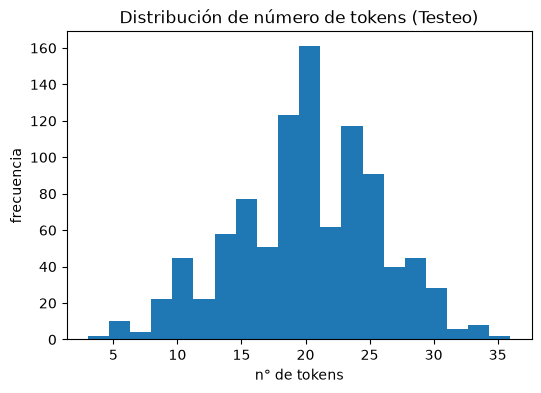

In [36]:
lengths = df_test["clean_tokens"].apply(len)

plt.figure(figsize = (6,4))
plt.hist(lengths, bins = 20)
plt.title("Distribución de número de tokens (Testeo)")
plt.xlabel("n° de tokens")
plt.ylabel("frecuencia")
plt.show()


4.1 Distribución de tokens de entrenamiento en cada etiqueta de sentimiento.

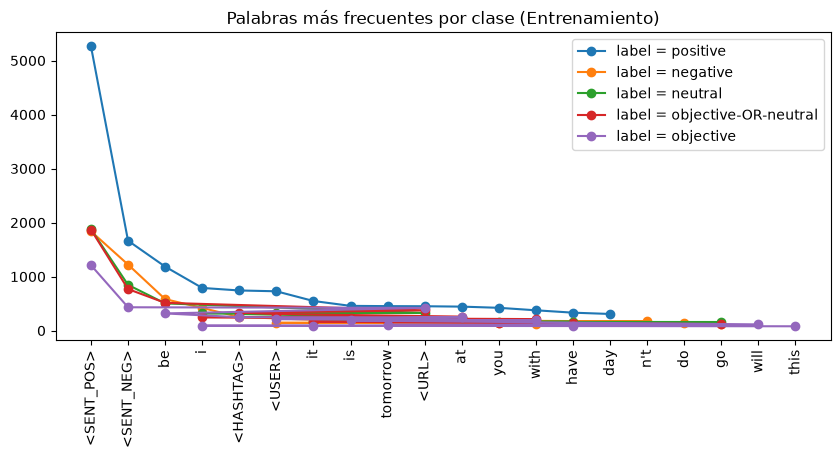

In [37]:
labels = df_train["label"].unique()

class_freqs = {}
for lab in labels:
    toks = [t for ts in df_train[df_train["label"] == lab]["clean_tokens"] for t in ts]
    class_freqs[lab] = Counter(toks)

top_k = 15

plt.figure(figsize = (10, 4))

for lab in labels:
    common = class_freqs[lab].most_common(top_k)
    words = [w for w,_ in common]
    counts = [c for _,c in common]
    plt.plot(words, counts, marker = 'o', label = f"label = {lab}")

plt.xticks(rotation = 90)
plt.legend()
plt.title("Palabras más frecuentes por clase (Entrenamiento)")
plt.show()


4.2 Distribución de tokens de testeo en cada etiqueta de sentimiento.

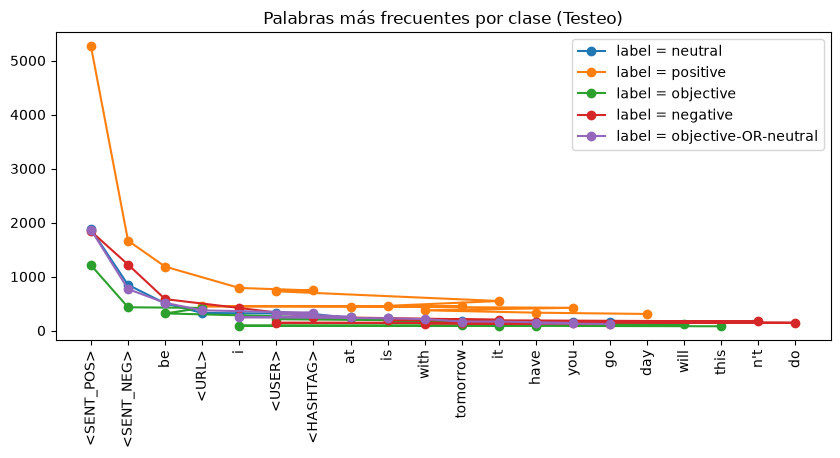

In [38]:
labels = df_test["label"].unique()

class_freqs = {}
for lab in labels:
    toks = [t for ts in df_train[df_train["label"] == lab]["clean_tokens"] for t in ts]
    class_freqs[lab] = Counter(toks)

top_k = 15

plt.figure(figsize = (10, 4))

for lab in labels:
    common = class_freqs[lab].most_common(top_k)
    words = [w for w,_ in common]
    counts = [c for _,c in common]
    plt.plot(words, counts, marker = 'o', label = f"label = {lab}")

plt.xticks(rotation = 90)
plt.legend()
plt.title("Palabras más frecuentes por clase (Testeo)")
plt.show()


5.1 Cantidad de tokens especiales de entrenamiento (URLs, USERS, HASHTAGS y resultados de SentiWordNet)

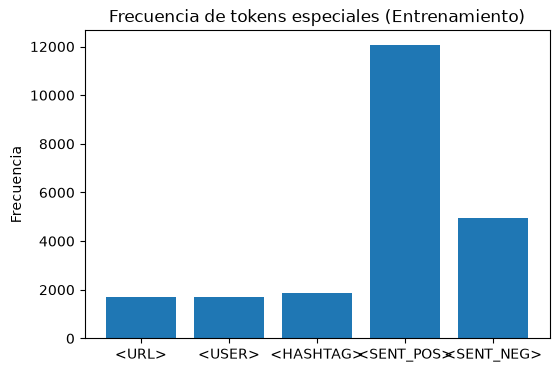

In [39]:
special_tokens = ["<URL>", "<USER>", "<HASHTAG>"]
for pol in ["<SENT_POS>", "<SENT_NEG>"]:
    special_tokens.append(pol)

counts = [freq_train.get(tok, 0) for tok in special_tokens]

plt.figure(figsize=(6,4))
plt.bar(special_tokens, counts)
plt.title("Frecuencia de tokens especiales (Entrenamiento)")
plt.ylabel("Frecuencia")
plt.show()

5.2 Cantidad de tokens especiales de testeo (URLs, USERS, HASHTAGS y resultados de SentiWordNet)

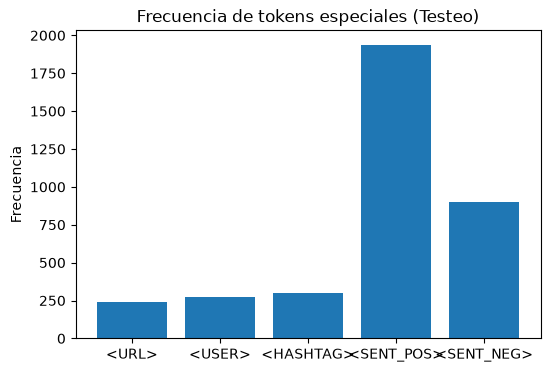

In [40]:
special_tokens = ["<URL>", "<USER>", "<HASHTAG>"]
for pol in ["<SENT_POS>", "<SENT_NEG>"]:
    special_tokens.append(pol)

counts = [freq_test.get(tok, 0) for tok in special_tokens]

plt.figure(figsize=(6,4))
plt.bar(special_tokens, counts)
plt.title("Frecuencia de tokens especiales (Testeo)")
plt.ylabel("Frecuencia")
plt.show()

6.1 Crecimiento de vocabulario de entrenamiento.

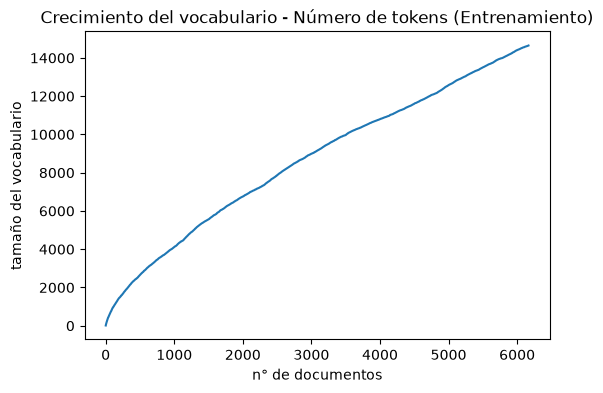

In [41]:
seen = set()
vocab_sizes = []
docs_seen = []

for i, toks in enumerate(df_train["clean_tokens"], start = 1):
    for t in toks:
        seen.add(t)
    vocab_sizes.append(len(seen))
    docs_seen.append(i)

plt.figure(figsize = (6, 4))
plt.plot(docs_seen, vocab_sizes)
plt.title("Crecimiento del vocabulario - Número de tokens (Entrenamiento)")
plt.xlabel("n° de documentos")
plt.ylabel("tamaño del vocabulario")
plt.show()

6.2 Crecimiento de vocabulario de testeo.

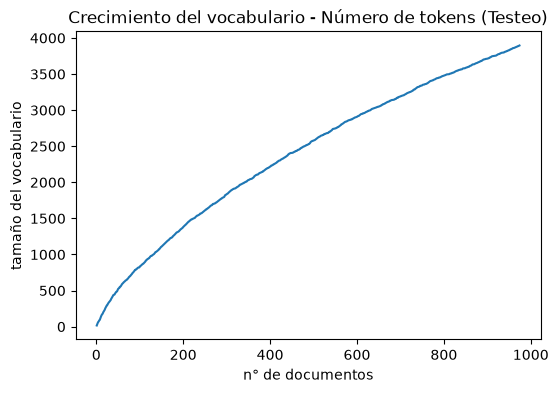

In [42]:
seen = set()
vocab_sizes = []
docs_seen = []

for i, toks in enumerate(df_test["clean_tokens"], start = 1):
    for t in toks:
        seen.add(t)
    vocab_sizes.append(len(seen))
    docs_seen.append(i)

plt.figure(figsize = (6, 4))
plt.plot(docs_seen, vocab_sizes)
plt.title("Crecimiento del vocabulario - Número de tokens (Testeo)")
plt.xlabel("n° de documentos")
plt.ylabel("tamaño del vocabulario")
plt.show()

7.1 Distribución de PoS tagging de entrenamiento.

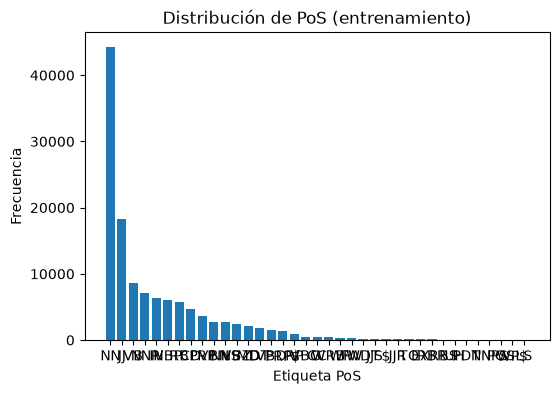

In [43]:
all_tagged = []

for toks in df_train["clean_tokens"]:
    all_tagged.extend(pos_tag(toks))

pos_counts = Counter(tag for _, tag in all_tagged)

tags, counts = zip(*pos_counts.most_common())

plt.figure(figsize=(6,4))
plt.bar(tags, counts)
plt.title("Distribución de PoS (entrenamiento)")
plt.xlabel("Etiqueta PoS")
plt.ylabel("Frecuencia")
plt.show()

7.2 Distribución de PoS tagging de testeo.

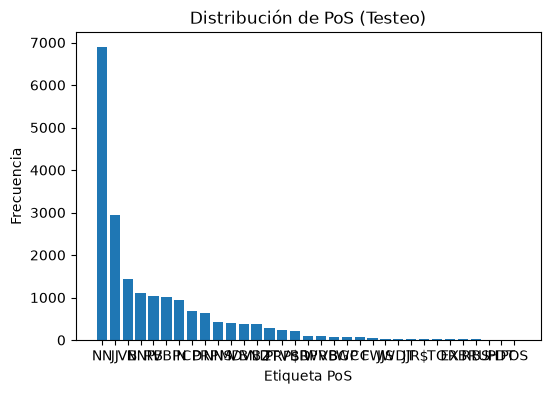

In [44]:
all_tagged = []

for toks in df_test["clean_tokens"]:
    all_tagged.extend(pos_tag(toks))

pos_counts = Counter(tag for _, tag in all_tagged)

tags, counts = zip(*pos_counts.most_common())

plt.figure(figsize=(6,4))
plt.bar(tags, counts)
plt.title("Distribución de PoS (Testeo)")
plt.xlabel("Etiqueta PoS")
plt.ylabel("Frecuencia")
plt.show()

8.1 Bigramas de entrenamiento (Combinaciones de dos tokens) más frecuentes.

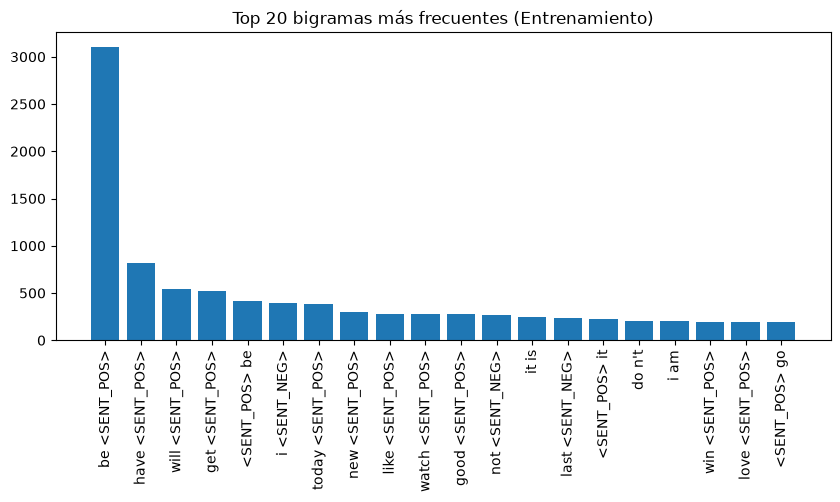

In [45]:
bigrams = []

for toks in df_train["clean_tokens"]:
    for i in range(len(toks) - 1):
        bigrams.append((toks[i], toks[i + 1]))

bigram_freq = Counter(bigrams)
top_bi = bigram_freq.most_common(20)

labels_bi = [" ".join(b) for b,_ in top_bi]
counts_bi = [c for _,c in top_bi]

plt.figure(figsize = (10, 4))
plt.bar(labels_bi, counts_bi)
plt.xticks(rotation = 90)
plt.title("Top 20 bigramas más frecuentes (Entrenamiento)")
plt.show()

8.2 Bigramas de testeo (Combinaciones de dos tokens) más frecuentes.

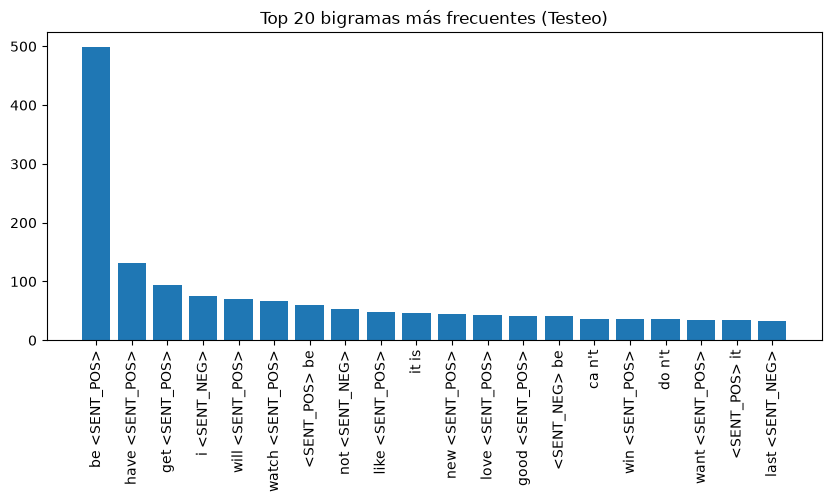

In [46]:
bigrams = []

for toks in df_test["clean_tokens"]:
    for i in range(len(toks) - 1):
        bigrams.append((toks[i], toks[i + 1]))

bigram_freq = Counter(bigrams)
top_bi = bigram_freq.most_common(20)

labels_bi = [" ".join(b) for b,_ in top_bi]
counts_bi = [c for _,c in top_bi]

plt.figure(figsize = (10, 4))
plt.bar(labels_bi, counts_bi)
plt.xticks(rotation = 90)
plt.title("Top 20 bigramas más frecuentes (Testeo)")
plt.show()

9 Tokens vistos en el entrenamiento VS tokens nuevos descubiertos en el testeo.

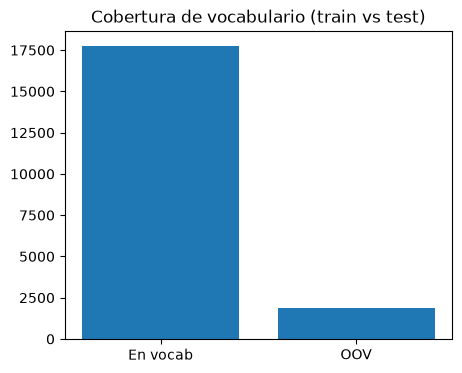

In [47]:
train_vocab = set(all_train_tokens)
test_tokens = [tok for toks in df_test["clean_tokens"] for tok in toks]

oov = [t for t in test_tokens if t not in train_vocab]

total_test_tokens = len(test_tokens)
total_oov = len(oov)

plt.figure(figsize = (5, 4))
plt.bar(["En vocab", "OOV"], [total_test_tokens - total_oov, total_oov])
plt.title("Cobertura de vocabulario (train vs test)")
plt.show()

10.1 Tokens de entrenamiento por rango de frecuencia. (Cuantas veces se repiten los tokens)

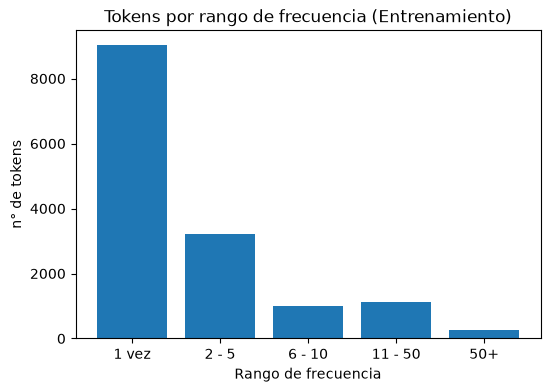

In [48]:
freq_values = list(freq_train.values())

buckets = {
    "1 vez": sum(1 for f in freq_values if f == 1),
    "2 - 5": sum(1 for f in freq_values if 2 <= f <= 5),
    "6 - 10": sum(1 for f in freq_values if 6 <= f <= 10),
    "11 - 50": sum(1 for f in freq_values if 11 <= f <= 50),
    "50+": sum(1 for f in freq_values if f > 50),
}

plt.figure(figsize = (6,4))
plt.bar(buckets.keys(), buckets.values())
plt.title("Tokens por rango de frecuencia (Entrenamiento)")
plt.xlabel("Rango de frecuencia")
plt.ylabel("n° de tokens")
plt.show()

10.2 Tokens de testeo por rango de frecuencia. (Cuantas veces se repiten los tokens)

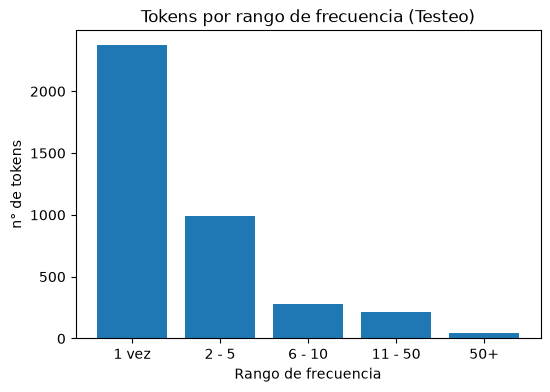

In [49]:
freq_values = list(freq_test.values())

buckets = {
    "1 vez": sum(1 for f in freq_values if f == 1),
    "2 - 5": sum(1 for f in freq_values if 2 <= f <= 5),
    "6 - 10": sum(1 for f in freq_values if 6 <= f <= 10),
    "11 - 50": sum(1 for f in freq_values if 11 <= f <= 50),
    "50+": sum(1 for f in freq_values if f > 50),
}

plt.figure(figsize = (6,4))
plt.bar(buckets.keys(), buckets.values())
plt.title("Tokens por rango de frecuencia (Testeo)")
plt.xlabel("Rango de frecuencia")
plt.ylabel("n° de tokens")
plt.show()

### 3. Uso de taxonomías léxicas especializadas y elementos no textuales.

##### Transformación de emojis

En el caso del data-set distribuido para esta actividad no se encuentran Emojis. Por lo tanto la solución de los emojis no se utiliza. Pero lo que se hizo para enriquecer el análisis de vocabulario fue crear un diccionario en el que entrega lo que significa cada emoji recibido.

##### Transformación de hashtags

Lo que se hizo para tomar en cuenta los hashtags fue el tokenizar el '#' como <HASHTAG>, y separar las palabras por mayusculas o guinos bajos para tokenizarlas individualmente.

##### Enriquecimiento con SentiWordNet / EmoLex

Se realizó una implementación de SentiWordNet, la cual recibe la palabra a análizar, que tipo de palabra es (verbo, sustantivo, adjetivo o adverbio) es decir su PoS tag; en el caso que la palabra esté en SentiWordNet, nos devuelve la probabilidad de los posibles significados de la palabra. (pos, neg, neu). Si no lo esta, no devuelve nada.

En el ciclo de tokenización, dependiendo del resultado de la implementación de SentiWordNet, se tokeniza SENT_POS, SENT_NEU, SENT_NEG o la palabra tal cual.

### 4. 20 Experimentos con entrenamientos de modelo ML supervisado con PLN.

Preparación de datos.

In [50]:
# Convertir lista de tokens → string para los vectorizadores de sklearn
X_train_text = df_train["clean_tokens"].apply(lambda toks: " ".join(toks))
X_test_text  = df_test["clean_tokens"].apply(lambda toks: " ".join(toks))

# Extraer etiquetas de sentimiento:
y_train = df_train["label"]
y_test  = df_test["label"]

In [51]:
print(X_train_text)

0        gas by my house hit 3.39 i am go chapel hill sat
1       iranian general say israel is iron dome <SENT_...
2       with j davlar 11th main <SENT_POS> rival be <S...
3       talk about act is sat is decide where i want <...
4       they may have <SENT_POS> superbowl dallas but ...
                              ...                        
6160    <USER> stoney16 <USER> jeffmossdsr i would rec...
6161    rt <USER> mnfootng it is monday monday night f...
6162    all i know be <SENT_POS> road that lomardi sta...
6163    all blue white <SENT_NEG> fam we r meet at gol...
6164    i am pisseeedddd that i miss <SENT_NEG> kid cu...
Name: clean_tokens, Length: 6165, dtype: str


Función para automatizar experimentos.

In [52]:
experiments = []

def run_exp(name, vectorizer, clf, X_train_override=None, X_test_override=None):

    # Generar Pipeline con vectorizador y clf:
    pipe = Pipeline([
        ("vect", vectorizer),
        ("clf", clf)
    ])


    Xtr = X_train_text if X_train_override is None else X_train_override
    Xte = X_test_text if X_test_override is None else X_test_override


    # Entrenar modelo
    pipe.fit(X_train_text, y_train)

    # Testear experimento
    y_pred = pipe.predict(X_test_text)

    # Calcular accuracy del experimento
    acc = accuracy_score(y_test, y_pred)


    # Guardar los nombres y calificación de todos los experimentos:
    experiments.append({
        "name": name,
        "accuracy": acc
    })

    # Print nombre y accuracy del experimento
    print(f"{name}: {acc:.4f}")


#### Listado de los 20 Experimentos, variando el modelo de machine learning, método de vectorización, etc.

01_BoW_1gram_NB

Utiliza Bag of Words solo con unigramas (palabras individuales) y Multinomial Naive Bayes.

Es el baseline básico para un clasificador de texto supervisado. Sirve como punto de partida, para saber si los demás experimentos mejoran.

In [53]:
# 1) Bag of Words unigram + Naive Bayes (baseline mínimo)
run_exp(
    "01_BoW_1gram_NB",
    CountVectorizer(ngram_range = (1,1), min_df = 2),
    MultinomialNB()
)

01_BoW_1gram_NB: 0.4261


02_BoW_1-2gram_NB

Mismo modelo (Naive Bayes) pero ahora la representación vectorial incluye unigramas y bigramas.

Mchas expresiones de sentimiento son de 2 palabras (“not good”, “very happy”), y el modelo puede aprovecharlas si están presentes.

In [54]:
# 2) Bag of Words 1-2 grams + Naive Bayes
run_exp(
    "02_BoW_1-2gram_NB",
    CountVectorizer(ngram_range = (1, 2), min_df = 2),
    MultinomialNB()
)

02_BoW_1-2gram_NB: 0.4281


03_TFIDF_1-2gram_NB

Misma idea que el experimento anterior, pero cambia la representación vectorial a TF-IDF.
Con el objetivo de ver si ponderar por rareza ayudaba al modelo.

In [55]:
# 3) TF-IDF 1-2 grams + Naive Bayes
run_exp(
    "03_TFIDF_1-2gram_NB",
    TfidfVectorizer(ngram_range = (1,2), min_df = 2),
    MultinomialNB()
)

03_TFIDF_1-2gram_NB: 0.3706


04_TFIDF_1gram_LogReg

Se utiliza nuevamente TF-IDF con unigramas para la representación vectorial, ahora cambia el modelo a uno de Regresión Logística.
Con el mismo pipeline, pero cambiando el modelo peude variar el resultado del rendimiento.

In [56]:
# 4) TF-IDF 1gram + Logistic Regression
run_exp(
    "04_TFIDF_1gram_LogReg",
    TfidfVectorizer(ngram_range = (1, 1), min_df = 2),
    LogisticRegression(max_iter = 1500)
)

04_TFIDF_1gram_LogReg: 0.4517


05_OneHot_BoW_binary_NB

Ahora cambiamos la representación a Bag of Words binario (binary = True), es decir, one-hot-encoding (aparece / no aparece), sin contar repeticiones. Con el modelo Naive Bayes.

In [57]:
# 5) One-hot (BoW_binary = True) + Naive Bayes
run_exp(
    "05_OneHot_BoW_binary_NB",
    CountVectorizer(ngram_range = (1, 1), min_df = 1, binary = True),
    MultinomialNB()
)

05_OneHot_BoW_binary_NB: 0.3963


06_TFIDF_1-2gram_SVM

TF-IDF con unigramas y bigramas + Linear SVM.
Estos parámetros tambien es uno de los más usados para clasificación de texto: TF-IDF + SVM lineal.

In [58]:
# 6) TF-IDF 1-2 grams + LinearSVC
run_exp(
    "06_TFIDF_1-2gram_SVM",
    TfidfVectorizer(ngram_range = (1, 2), min_df = 2),
    LinearSVC()
)

06_TFIDF_1-2gram_SVM: 0.4446


07_TFIDF_1-3gram_SVM

Misma configuración que el experimento anterior, pero ahora incluyendo trigramas.

Ver si más contexto (3 palabras) ayuda a capturar frases típicas de sentimiento.

In [59]:
# 7) TF-IDF 1-3 grams + LinearSVC
run_exp(
    "07_TFIDF_1-3gram_SVM",
    TfidfVectorizer(ngram_range = (1, 3), min_df = 2),
    LinearSVC()
)

07_TFIDF_1-3gram_SVM: 0.4600


08_TFIDF_1-2gram_LogReg

Repetimos TF-IDF con 1–2 gram con Regresión Logística, pero ahora con más iteraciones.
Con el objetivo de comparar directamente contra SVM con la misma representación.

In [60]:
# 8) TF-IDF 1-2 grams + Logistic Regression
run_exp(
    "08_TFIDF_1-2gram_LogReg",
    TfidfVectorizer(ngram_range = (1, 2), min_df = 2),
    LogisticRegression(max_iter = 2000)
)

08_TFIDF_1-2gram_LogReg: 0.4548


09_TFIDF_char_3-5_SVM

En vez de palabras, usa n-gramas de caracteres (3 a 5) + SVM.

Los textos son de redes / con ruido / con hashtags; los n-gramas de caracteres suelen ser robustos a errores, abreviaturas y variantes.

In [61]:
# 9) TF-IDF de caracteres (3, 5) + SVM
run_exp(
    "09_TFIDF_char_3-5_SVM",
    TfidfVectorizer(analyzer="char", ngram_range = (3, 5), min_df = 2),
    LinearSVC()
)

09_TFIDF_char_3-5_SVM: 0.4415


10_BoW_1-2gram_SVM

Misma SVM que antes, pero cambiando la representación a Bag of Words (conteos) en lugar de TF-IDF.
Para comparar directamente BoW vs TF-IDF manteniendo el modelo fijo.

In [62]:
# 10) Bag of Words 1-2 grams + LinearSVC
run_exp(
    "10_BoW_1-2gram_SVM",
    CountVectorizer(ngram_range = (1, 2), min_df = 2),
    LinearSVC()
)

10_BoW_1-2gram_SVM: 0.4251


c:\Users\pedro\Documents\Documentos Tec\Semestre_7_Concentracion_IA\Advanced_IA_Implementation\env\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


1_TFIDF_1-2gram_SVM_4k

La misma ocnfiguración que el experimento 6, pero recorta el vocabulario a 4000 términos.

Para ver si limitar a las palabras más informativas reduce ruido y mejora el rendimiento.

In [63]:
# 11) TF-IDF 1-2 grams + SVM con vocab recortado
run_exp(
    "11_TFIDF_1-2gram_SVM_4k",
    TfidfVectorizer(ngram_range = (1, 2), min_df = 2, max_features = 4000),
    LinearSVC()
)

11_TFIDF_1-2gram_SVM_4k: 0.4271


12_BoW_1-2gram_MNB_3k

Bag of Words con 1–2 gram usando Naive Bayes, pero ahora con max_features = 3000.

Para probar el mismo recorte que en el 11 pero cambiando el modelo, ya que a veces mejora cuando quitas ruido.

In [64]:
# 12) Bag of Words 1-2 grams + MNB con vocab recortado
run_exp(
    "12_BoW_1-2gram_MNB_3k",
    CountVectorizer(ngram_range = (1, 2), min_df = 1, max_features = 3000),
    MultinomialNB()
)

12_BoW_1-2gram_MNB_3k: 0.4476


13_BoW_1-2gram_MNB_sin_SENT

Bag of Words con 1–2 gram con Naive Bayes, pero filtrando los tokens sintéticos de sentimiento (< SENT_POS >, < SENT_NEG >).

Con el objetivo de comparar contra la versión que sí los incluye, para ver si el enriquecimiento léxico ayudó o solo metió ruido.

In [65]:
# 13) Bag of Words 1-2 grams + MNB SIN tokens de sentimiento (SIN <SENT_POS> & <SENT_NEG>)
class FilterSentTokensVectorizer(CountVectorizer):
    def build_analyzer(self):
        analyzer = super().build_analyzer()
        def f(doc):
            return [t for t in analyzer(doc)
                    if not t.startswith("<SENT_") and not t.startswith("<sent_")]
        return f

run_exp(
    "13_BoW_1-2gram_MNB_sin_SENT",
    FilterSentTokensVectorizer(ngram_range = (1, 2), min_df = 2),
    MultinomialNB()
)

13_BoW_1-2gram_MNB_sin_SENT: 0.4281


14_TFIDF_1-2gram_SVM_con_SENT

TF-IDF + SVM sin filtrar los tokens < SENT_... >.

Por qué: el mismo análisis que el experimento anterior, pero ahora con un modelo más potente (SVM) que sí podría aprovechar esos tokens extra.

In [66]:
# 14) TF-IDF 1-2 grams + SVM CON tokens de sentimiento (CON <SENT_POS> & <SENT_NEG>)
run_exp(
    "14_TFIDF_1-2gram_SVM_con_SENT",
    TfidfVectorizer(ngram_range = (1, 2), min_df = 2),
    LinearSVC()
)

14_TFIDF_1-2gram_SVM_con_SENT: 0.4446


15_TFIDF_1-2gram_SVM_sin_especiales

Misma configuración qué el anterior; TF-IDF + SVM, pero antes de vectorizar se les quita los tokens súper frecuentes < URL >, < USER >, < HASHTAG >.

Para comprobar la hipótesis de que los tokens sociales muy frecuentes diluyen la señal.

In [67]:
# 15) TF-IDF 1-2 grams + SVM SIN tokens especiales (SIN <URL>, <USER>, <HASHTAG>)
specials = {"<url>", "<user>", "<hashtag>"}
X_train_nospec = X_train_text.apply(lambda s: " ".join([t for t in s.split() if t not in specials]))
X_test_nospec  = X_test_text.apply(lambda s: " ".join([t for t in s.split() if t not in specials]))

run_exp(
    "15_TFIDF_1-2gram_SVM_sin_especiales",
    TfidfVectorizer(ngram_range=(1,2), min_df=2),
    LinearSVC(),
    X_train_override=X_train_nospec,
    X_test_override=X_test_nospec
)

15_TFIDF_1-2gram_SVM_sin_especiales: 0.4446


16_TFIDF_1-2_SVM_plus_meta

Mezcla dos tipos de features:

- TF-IDF de texto

- Features numéricas de tu pipeline (exclamations, questions, has_hashtag)
y entrena una SVM.

Mostrar que las señales no textuales que se extrajeron en el preprocesamiento sí pueden aportar al modelo.

In [68]:
# 16) TF-IDF 1-2 grams + SVM + meta-features (exclamaciones, preguntas, hashtag)
from scipy.sparse import hstack
import numpy as np

vect_16 = TfidfVectorizer(ngram_range = (1,2), min_df = 2)
Xtr_text_16 = vect_16.fit_transform(X_train_text)
Xte_text_16 = vect_16.transform(X_test_text)

Xtr_meta_16 = np.array([[m["exclamations"], m["questions"], int(m["has_hashtag"])]
                        for m in df_train["meta"]])
Xte_meta_16 = np.array([[m["exclamations"], m["questions"], int(m["has_hashtag"])]
                        for m in df_test["meta"]])

Xtr_16 = hstack([Xtr_text_16, Xtr_meta_16])
Xte_16 = hstack([Xte_text_16, Xte_meta_16])

svc_16 = LinearSVC()
svc_16.fit(Xtr_16, y_train)
y_pred_16 = svc_16.predict(Xte_16)
acc_16 = accuracy_score(y_test, y_pred_16)
experiments.append({"name": "16_TFIDF_1-2_SVM_plus_meta", "accuracy": acc_16})
print(f"16_TFIDF_1-2_SVM_plus_meta: {acc_16:.4f}")


16_TFIDF_1-2_SVM_plus_meta: 0.4620


17_TFIDF_1-2gram_CompNB

Mismo TF-IDF que en los NB anteriores pero con Complement Naive Bayes (variante más robusta para clases desbalanceadas).

Para comparar NB “normal” vs NB “complement”.

In [69]:
# 17) Complement Naive Bayes sobre TF-IDF
run_exp(
    "17_TFIDF_1-2gram_CompNB",
    TfidfVectorizer(ngram_range = (1, 2), min_df = 2),
    ComplementNB()
)

17_TFIDF_1-2gram_CompNB: 0.4261


18_BoW_1gram_binary_MNB_alpha1

Bag of Words unigram binario + Naive Bayes pero con alpha = 1.0 (más suavizado).

Para probar si el smoothing ayuda cuando hay muchas palabras raras.

In [70]:
# 18) BoW 1gram, binary=True + MNB con alpha más alto (suavizado)
run_exp(
    "18_BoW_1gram_binary_MNB_alpha1",
    CountVectorizer(ngram_range = (1, 1), min_df = 2, binary = True),
    MultinomialNB(alpha = 1.0)
)


18_BoW_1gram_binary_MNB_alpha1: 0.4107


19_TFIDF_1-2gram_LogReg_C2

Igual que el experimento 8 (TF-IDF 1–2 con Regresión Logistica) pero con C más alto (más capacidad) y más iteraciones.

In [71]:
# 19) TF-IDF 1-2 grams + LogisticRegression con C más alto
run_exp(
    "19_TFIDF_1-2gram_LogReg_C2",
    TfidfVectorizer(ngram_range = (1, 2), min_df = 2),
    LogisticRegression(max_iter = 2000, C = 2.0)
)

19_TFIDF_1-2gram_LogReg_C2: 0.4651


20_TFIDF_1-2gram_LogReg_balanced

Misma Regresión Logística, pero con class_weight="balanced".

Para evaluar si había desbalance de clases que estuviera afectando el accuracy.

In [72]:
# 20) TF-IDF 1-2 grams + LogisticRegression con class_weight=balanced
run_exp(
    "20_TFIDF_1-2gram_LogReg_balanced",
    TfidfVectorizer(ngram_range = (1, 2), min_df = 2),
    LogisticRegression(max_iter = 2000, class_weight = "balanced")
)

20_TFIDF_1-2gram_LogReg_balanced: 0.4251


### 5. Comparación de resultados entre los 20 experimentos.

,name,accuracy
18,19_TFIDF_1-2gram_LogReg_C2,0.465092
15,16_TFIDF_1-2_SVM_plus_meta,0.462012
6,07_TFIDF_1-3gram_SVM,0.459959
7,08_TFIDF_1-2gram_LogReg,0.454825
3,04_TFIDF_1gram_LogReg,0.451745
11,12_BoW_1-2gram_MNB_3k,0.447639
13,14_TFIDF_1-2gram_SVM_con_SENT,0.444559
14,15_TFIDF_1-2gram_SVM_sin_especiales,0.444559
5,06_TFIDF_1-2gram_SVM,0.444559
8,09_TFIDF_char_3-5_SVM,0.441478


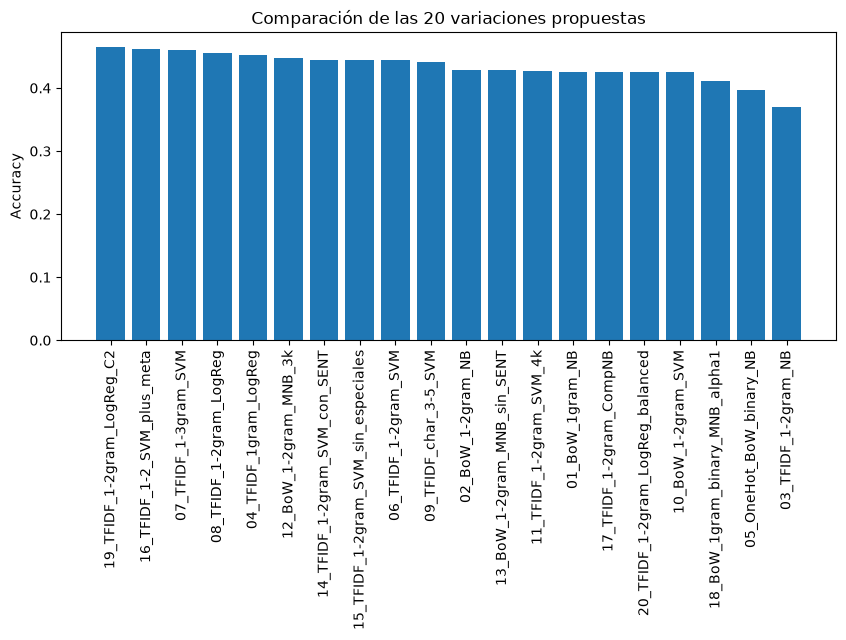

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# Tabla ordenada de mejor a peor 'Accuracy'
exp_df = pd.DataFrame(experiments).sort_values("accuracy", ascending=False)
display(exp_df)

# Distribución de Accuracy entre los 20 experimentos
plt.figure(figsize = (10, 4))
plt.bar(exp_df["name"], exp_df["accuracy"])
plt.xticks(rotation = 90)
plt.ylabel("Accuracy")
plt.title("Comparación de las 20 variaciones propuestas")
plt.show()

### 6. Conclusiones.

#### Ventajas y desventajas de las representaciones vectoriales:


### Bag of Words (BoW: uni/bi-gramas)

* **Ventajas:** simple y rápido; buen baseline; bigramas capturan negaciones/modificadores (“not good”).
* **Desventajas:** no pondera rareza; sensible a ruido; vocab grande → sparsity/overfit; bigramas dependen del tamaño/calidad del corpus.

### One-hot (BoW binario)

* **Ventajas:** presencia/ausencia clara; menos impacto de repeticiones.
* **Desventajas:** pierde intensidad (frecuencia); suele rendir peor que BoW/TF-IDF en textos cortos.

### TF-IDF (1, 1–2, 1–3)

* **Ventajas:** deprime términos comunes y realza distintivos; n-gramas cortos capturan contexto; base de tus mejores modelos (SVM/LogReg).
* **Desventajas:** con NB suele degradar; n-gramas largos con poco dato añaden ruido/sparsity.

### N-gramas de **caracteres** (3–5)

* **Ventajas:** robustos a typos/slang/emojis; capturan subpalabras.
* **Desventajas:** menos interpretables; riesgo de patrones superficiales si el corpus es pequeño.

### **Tokens especiales** normalizados (`<URL>`, `<USER>`, `<HASHTAG>`)

* **Ventajas:** colapsan variantes → vocab más compacto; buena señal de dominio.
* **Desventajas:** poco discriminativos para sentimiento; si abundan, diluyen señal (TF-IDF ya los penaliza).

### **Tokens de sentimiento** (SentiWordNet → `<SENT_POS>`, `<SENT_NEG>`)

* **Ventajas:** incorporan léxico externo; mejor generalización; aprovechan lematización+PoS.
* **Desventajas:** ambigüedad de sentidos (heurística del primer synset); pueden volverse casi constantes y aportar poco.

### **Meta-features** no textuales (`!`, `?`, `has_hashtag`)

* **Ventajas:** capturan énfasis/paralingüística que el texto no ve; en tu corpus +TF-IDF+SVM fueron top.
* **Desventajas:** pocas y simples; requieren fusión sparse+denso y monitoreo en producción.


#### Conclusiones generales.

El desarrollo de esta actividad me recordó la importancia que tiene la preparación de los datos a usar (el pipeline), sobre los parametros del modelo de machine learning utilizado.

Por esa importancia, existen diversas formas de limpiar y procesar los datos, así como diversas representaciones vectoriales.

Tambien se me demostró lo complicado que es para un modelo de machine learning el poder identificar adecuadamente los textos, ya que el promedio de accuracy en los 20 diversos experimentos es de 40%.

# Tarea 2: Uso de técnicas de PLN para representar texto

In [74]:
"""
Pedro Mauri Mtz - A01029143
Tarea 2: Uso de técnicas de PLN para representa texto
"""

'\nPedro Mauri Mtz - A01029143\nTarea 2: Uso de técnicas de PLN para representa texto\n'

## Entrenamiento de Regresión logística, únicamente variando la representación vectorial del texto

- BoW
- One-hot-encoding
- TF-IDF
- Modelo de N-gramas
- Modelo de Skip-gramas
- Word embeddings
- BERT
- Combinación (ensamble) de representaciones.

### Inicializar modelo de Regresión Logística

In [75]:
# Modelo a usar: Regresión Logística
base_clf = LogisticRegression(
    max_iter = 1000,
    n_jobs = -1,
    class_weight = None
)

### Inicialización de diccionario con las primeras 4 representaciones vectoriales

In [76]:
# Definir representaciones vectoriales:

vectorizers = {
    "BoW": CountVectorizer(
        ngram_range = (1, 1)
    ),
    "One_Hot": CountVectorizer(
        ngram_range = (1, 1),
        binary = True # Solo cuenta presencia (0 / 1)
    ),
    "TF_IDF": TfidfVectorizer(
        ngram_range = (1, 1)
    ),
    "N_gramas": TfidfVectorizer( # TF-IDF 1-2 gramas
        ngram_range = (1, 2), # uni + bi-gramas
        min_df = 2
    )
}

### Implementación de skip-gramas

In [77]:
def make_skip_gram_analyzer(max_skip = 2):

    def analyzer(doc):
        tokens = doc.split()
        n = len(tokens)

        # Unigramas (palabras individuales)
        for t in tokens:
            yield t

        # Skip-bigramas: (w_i, w_j) con j > i y j - i <= max_skip + 1
        for i in range(n):
            for j in range(i + 1, min(n, i + max_skip + 2)):
                yield tokens[i] + "__" + tokens[j]

    return analyzer

# Vectorizador de skip-grams (unigrams + skip-bigrams)
skip_grams_vectorizer = CountVectorizer(
    analyzer = make_skip_gram_analyzer(max_skip = 2)
)

In [78]:
# Agregarlo al diccionario de representaciones vectoriales
vectorizers["Skip_grams"] = skip_grams_vectorizer

### Implementación de embeddings

#### Embeddings propios

In [79]:
# Preparar datos para Word2Vec (Matriz de tokens en cada tweet)

sentences_train = [text.split() for text in X_train_text]
sentences_test  = [text.split() for text in X_test_text]

"""
for i in range(len(sentences_train)):
  print(sentences_train[i])

for i in range(len(sentences_test)):
  print(len(sentences_test[i]))
"""

'\nfor i in range(len(sentences_train)):\n  print(sentences_train[i])\n\nfor i in range(len(sentences_test)):\n  print(len(sentences_test[i]))\n'

In [80]:
# Entrenar propio modelo de embeddings (Word2Vec)

w2v_dim = 100

w2v_model = Word2Vec(
    sentences = sentences_train,
    vector_size = w2v_dim,
    window = 5,
    min_count = 2, # Ignorar palabras muy raras
    workers = 4,
    sg = 1 # 1 = skip-gram, 0 = CBOW
)

In [81]:
# Función para convertir un tweet en vector promedio

def document_vector_w2v(doc, model, vector_size):
    # doc: string (tweet preprocesado)
    # model: modelo Word2Vec entrenado
    # vector_size: dimensión del embedding

    tokens = doc.split()

    # Nos quedamos solo con tokens que existan en el vocabulario del modelo
    valid_tokens = [w for w in tokens if w in model.wv]

    if not valid_tokens:
        return np.zeros(vector_size)

    return np.mean(model.wv[valid_tokens], axis = 0)

In [82]:
# Matrices de embeddings promedio

X_train_w2v = np.vstack([
    document_vector_w2v(doc, w2v_model, w2v_dim)
    for doc in X_train_text
])

X_test_w2v = np.vstack([
    document_vector_w2v(doc, w2v_model, w2v_dim)
    for doc in X_test_text
])

print(X_train_w2v.shape, X_test_w2v.shape)

(6165, 100) (974, 100)


#### Embeddings con pre-entrenamiento

In [83]:
# Descarga de modelo pre-entrenado (Glove Twitter 25)

pretrained_wv = api.load("glove-twitter-25")
pretrained_dim = pretrained_wv.vector_size

[==================================================] 100.0% 104.8/104.8MB downloaded


In [84]:
# Función para convertir un tweet en vector promedio (CON MODELO PRE-ENTRENADO)

def document_vector_pretrained(doc, wv, vector_size):

    tokens = doc.split()

    # Nos quedamos con las palabras que estén en el vocabulario del modelo pre-entrenado
    valid_tokens = [w for w in tokens if w in wv.key_to_index]

    if not valid_tokens:
        return np.zeros(vector_size)

    return np.mean([wv[w] for w in valid_tokens], axis = 0)

In [85]:
# Matrices de embeddings promedio (CON MODELO PRE-ENTRENADO)

X_train_glove = np.vstack([
    document_vector_pretrained(doc, pretrained_wv, pretrained_dim)
    for doc in X_train_text
])

X_test_glove = np.vstack([
    document_vector_pretrained(doc, pretrained_wv, pretrained_dim)
    for doc in X_test_text
])

print(X_train_glove.shape, X_test_glove.shape)

(6165, 25) (974, 25)


## Implementación de BERT

In [86]:
# Priorizar uso de GPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [87]:
# Inicializar el modelo ya creado de BERT

bert_model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name)
bert_model.to(device)

# Evaluación sin dropout de entrenamiento
bert_model.eval()

c:\Users\pedro\Documents\Documentos Tec\Semestre_7_Concentracion_IA\Advanced_IA_Implementation\env\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pedro\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 100/100 [00:0

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=Tru

In [88]:
# Convertir textos a Embeddings BERT

def encode_texts_bert(texts, tokenizer, model, batch_size = 25, max_length = 50, device = "cpu"):

    all_embeddings = []

    # Asegurarnos de poder iterar como lista
    if not isinstance(texts, (list, tuple)):
        texts = list(texts)

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]

        # Tokenización
        encoded = tokenizer(
            batch_texts,
            padding = True,
            truncation = True,
            max_length = max_length,
            return_tensors = "pt"
        )

        # Mover a GPU/CPU
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():

            outputs = model(**encoded)

            last_hidden = outputs.last_hidden_state

            attention_mask = encoded["attention_mask"].unsqueeze(-1)
            masked_hidden = last_hidden * attention_mask

            sum_embeddings = masked_hidden.sum(dim = 1)

            lengths = attention_mask.sum(dim = 1)

            lengths = torch.clamp(lengths, min = 1)

            sentence_embeddings = sum_embeddings / lengths

        all_embeddings.append(sentence_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

In [89]:
# Obtener features BERT

X_train_bert = encode_texts_bert(
    X_train_text,
    tokenizer,
    bert_model,
    batch_size = 25,
    max_length = 50,
    device=device
)

X_test_bert = encode_texts_bert(
    X_test_text,
    tokenizer,
    bert_model,
    batch_size = 25,
    max_length = 50,
    device=device
)

print(X_train_bert.shape, X_test_bert.shape)

(6165, 768) (974, 768)


## Implementación de combinación de representaciones

### Propuesta: N Gramas (TF-IDF, 1-2 Gramas) + BERT

#### Justificación:

TF-IDF 1-2 Gramas captura palabras y expresiones específicas del dataset (hashtags, modismos, errores ortográficos) que BERT no suele manejar adecuadamente. Por otra parte, los bi-gramas suelen ayudar aportando valor sentimental ("not good", "very happy").

Por otro lado, BERT captura contexto y relaciones semánticas, es más robusto a variaciones léxicas y a frases más complejas.

- TF-IDF ve exactamente qué palabras y n-gramas aparecen.

- BERT ve qué quieren decir esas frases en contexto.

In [90]:
# Construir TF-IDF 1-2 Gramas

# Tomamos el vectorizador de TF-IDF con 1-2 grams
tfidf_12 = vectorizers["N_gramas"]

# Lo ajustamos sobre el conjunto de entrenamiento
X_train_tfidf = tfidf_12.fit_transform(X_train_text)
X_test_tfidf = tfidf_12.transform(X_test_text)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(6165, 16527) (974, 16527)


In [91]:
# Escalar BERT

scaler_bert = StandardScaler()

# Escalamos las matrizes de BERT
X_train_bert_scaled = scaler_bert.fit_transform(X_train_bert)
X_test_bert_scaled = scaler_bert.transform(X_test_bert)

print(X_train_bert_scaled.shape, X_test_bert_scaled.shape)

(6165, 768) (974, 768)


In [92]:
# COMBINAR REPRESENTACIONES VECTORIALES

# Convertir BERT escalado a matriz dispersa
X_train_bert_sparse = csr_matrix(X_train_bert_scaled)
X_test_bert_sparse = csr_matrix(X_test_bert_scaled)

# Concatenar características: [TF-IDF | BERT]
X_train_ens = hstack([X_train_tfidf, X_train_bert_sparse])
X_test_ens = hstack([X_test_tfidf, X_test_bert_sparse])

print(X_train_ens.shape, X_test_ens.shape)

(6165, 17295) (974, 17295)


En el ensamble combinamos representaciones de distinta naturaleza:

- N-Gramas (TF-IDF de 1–2 Gramas): Valores dispersos de tipo frecuencia ponderada.

- Embeddings de BERT: Vectores densos de activaciones continuas.

Como los rangos numéricos de cada representación son diferentes (frecuencias, pesos TF-IDF, activaciones densas), antes de concatenarlas:

1. Se aplica StandardScaler sobre el bloque denso de BERT para obtener atributos con media 0 y varianza 1.

2. Se mantiene el bloque TF-IDF en su escala natural (ya que ya esta normalizado), y concatenamos ambos bloques en una única matriz de características dispersa.

De esta forma se evita que uno de los bloques domine el entrenamiento solo por tener valores numéricamente mayores, y se permite que el clasificador aproveche la información complementaria de ambos espacios de representación.

## Entrenamiento y testeo de un modelo de Regresión Logistica con TODAS de las representaciones vectoriales

In [93]:
# Entrenamiento con las representaciones vectoriales

results = []

# Iterar entre las representaciones vectoriales:
for name, vec in vectorizers.items():

    print("=" * 61 + "\n")
    print(f"Representación: {name}\n")

    pipe = Pipeline([
        ("vect", vec),
        ("clf", base_clf)
    ])

    # Entrenamiento
    pipe.fit(X_train_text, y_train)

    # Predicción
    y_pred = pipe.predict(X_test_text)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average = "macro")

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 macro: {f1_macro:.4f}")
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred))

    results.append({
        "representation": name,
        "accuracy": acc,
        "f1_macro": f1_macro
    })

print("=" * 61 + "\n")
print("Representación: Embeddings (propios) \n")

# Entrenamiento con embeddings propios
base_clf.fit(X_train_w2v, y_train)

# Predicción con embeddings propios
y_pred_w2v = base_clf.predict(X_test_w2v)

# Re-definir métricas con embeddgins propios
acc = accuracy_score(y_test, y_pred_w2v)
f1_macro = f1_score(y_test, y_pred_w2v, average = "macro")

print(f"Accuracy: {acc:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_w2v))

results.append({
    "representation": "Embeddings_Propios_(Word2Vec_own)",
    "accuracy": acc,
    "f1_macro": f1_macro
})

print("=" * 61 + "\n")
print("Representación: Embeddings (con pre-entrenamiento) \n")

# Entrenamiento con embeddings pre-entrenados
base_clf.fit(X_train_glove, y_train)

# Predicción con embeddings pre-entrenados
y_pred_glove = base_clf.predict(X_test_glove)

# Re-definir métricas con embeddgins pre-entrenados
acc = accuracy_score(y_test, y_pred_glove)
f1_macro = f1_score(y_test, y_pred_glove, average = "macro")

print(f"Accuracy: {acc:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_glove))

results.append({
    "representation": "Embeddings_Pre_entrenados_(Glove_Twitter_25)",
    "accuracy": acc,
    "f1_macro": f1_macro
})

print("=" * 61 + "\n")
print("Representación: BERT \n")

# Entrenamiento con embeddings pre-entrenados
base_clf.fit(X_train_bert, y_train)

# Predicción con embeddings pre-entrenados
y_pred_bert = base_clf.predict(X_test_bert)

# Re-definir métricas con embeddgins pre-entrenados
acc = accuracy_score(y_test, y_pred_bert)
f1_macro = f1_score(y_test, y_pred_bert, average = "macro")

print(f"Accuracy: {acc:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_bert))

results.append({
    "representation": "BERT",
    "accuracy": acc,
    "f1_macro": f1_macro
})

print("=" * 61 + "\n")

print("=" * 61 + "\n")
print("Representación: Ensamble (N-Gramas + BERT) \n")

# Entrenamiento con ensamble
base_clf.fit(X_train_ens, y_train)

# # Predicción con ensamble
y_pred_ens = base_clf.predict(X_test_ens)

# Re-definir métricas con ensamble
acc = accuracy_score(y_test, y_pred_ens)
f1_macro = f1_score(y_test, y_pred_ens, average = "macro")

print(f"Accuracy: {acc:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_ens))

results.append({
    "representation": "Ensamble",
    "accuracy": acc,
    "f1_macro": f1_macro
})


Representación: BoW



c:\Users\pedro\Documents\Documentos Tec\Semestre_7_Concentracion_IA\Advanced_IA_Implementation\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.4466
F1 macro: 0.3465

Classification report:

                      precision    recall  f1-score   support

            negative       0.53      0.38      0.44       179
             neutral       0.43      0.25      0.32       330
           objective       0.07      0.23      0.11        30
objective-OR-neutral       0.15      0.29      0.20        77
            positive       0.62      0.71      0.66       358

            accuracy                           0.45       974
           macro avg       0.36      0.37      0.35       974
        weighted avg       0.49      0.45      0.45       974


Representación: One_Hot



c:\Users\pedro\Documents\Documentos Tec\Semestre_7_Concentracion_IA\Advanced_IA_Implementation\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.4600
F1 macro: 0.3576

Classification report:

                      precision    recall  f1-score   support

            negative       0.58      0.40      0.47       179
             neutral       0.46      0.25      0.32       330
           objective       0.07      0.23      0.10        30
objective-OR-neutral       0.17      0.31      0.22        77
            positive       0.61      0.74      0.67       358

            accuracy                           0.46       974
           macro avg       0.38      0.39      0.36       974
        weighted avg       0.50      0.46      0.46       974


Representación: TF_IDF



...

Accuracy: 0.4045
F1 macro: 0.2610

Classification report:

                      precision    recall  f1-score   support

            negative       0.46      0.46      0.46       179
             neutral       0.50      0.04      0.07       330
           objective       0.06      0.17      0.09        30
objective-OR-neutral       0.11      0.09      0.10        77
            positive       0.46      0.80      0.59       358

            accuracy                           0.40       974
           macro avg       0.32      0.31      0.26       974
        weighted avg       0.43      0.40      0.34       974


Representación: BERT 



c:\Users\pedro\Documents\Documentos Tec\Semestre_7_Concentracion_IA\Advanced_IA_Implementation\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.4641
F1 macro: 0.3545

Classification report:

                      precision    recall  f1-score   support

            negative       0.57      0.57      0.57       179
             neutral       0.52      0.19      0.28       330
           objective       0.06      0.23      0.10        30
objective-OR-neutral       0.15      0.21      0.17        77
            positive       0.59      0.73      0.65       358

            accuracy                           0.46       974
           macro avg       0.38      0.39      0.35       974
        weighted avg       0.51      0.46      0.46       974



Representación: Ensamble (N-Gramas + BERT) 



c:\Users\pedro\Documents\Documentos Tec\Semestre_7_Concentracion_IA\Advanced_IA_Implementation\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.4476
F1 macro: 0.3509

Classification report:

                      precision    recall  f1-score   support

            negative       0.54      0.51      0.52       179
             neutral       0.46      0.23      0.30       330
           objective       0.08      0.30      0.12        30
objective-OR-neutral       0.12      0.21      0.15        77
            positive       0.62      0.68      0.65       358

            accuracy                           0.45       974
           macro avg       0.36      0.39      0.35       974
        weighted avg       0.50      0.45      0.46       974



## Resultados de Entrenamientos y pruebas

In [94]:
results_df = pd.DataFrame(results).sort_values(by = "accuracy", ascending = False)
print(results_df)

                                 representation  accuracy  f1_macro
7                                          BERT  0.464066  0.354523
1                                       One_Hot  0.459959  0.357635
2                                        TF_IDF  0.455852  0.329750
3                                      N_gramas  0.454825  0.324145
8                                      Ensamble  0.447639  0.350896
0                                           BoW  0.446612  0.346500
4                                    Skip_grams  0.444559  0.331025
6  Embeddings_Pre_entrenados_(Glove_Twitter_25)  0.404517  0.260987
5             Embeddings_Propios_(Word2Vec_own)  0.386037  0.233488


## Documentación de las pruebas y comparación de representaciones

Para esta actividad se estableció la Regresión Logística como modelo de machine learning a utilizar. Se entrenó y probó con cada una de las representaciones vectoriales anteriormente mencionadas.

(BoW, One-hot-encoding, TF-IDF, N-Gramas, Skip-Gramas, Word embeddings propio, Word embeddings pre-entrenado,
BERT y un ensamble entre N-Gramas y BERT).

Las métricas derendimiento que se usaron en todas las pruebas fueron:
- F1 (Macro)
- Accuracy

Primero, se probó con las representaciones clásicas, y los resultados entre sí no variaron demasiado, mostrando que la ponderación por frecuencia inversa no necesariamente se tradujo en una mejora clara frente a las representaciones binarias, aunque se mantuvo competitiva.

Después se incorporó los modelos N-Gramas, el cuál tuvo un mejor accuracy que las primeras 4 representaciones. Por otro lado, los resultados de Skip-Gramas no cambairon mucho en comparación; Lo que implica que la inclusión de relaciones no contiguas entre palabras no aportó una mejora significativa.

A continuación, se implementó los Word Embeddings (propios y con pre-entrenamiento), en este caso la implementación de embeddings propios fue la que tuvo peor accuracy de manera general, mientras que los pre-entrenados semostraron superiores a los propios (lo cual hace lógica). Pero, en ambos casos, representar cada tweet como el promedio de los vectores de palabras no logró competir con las representaciones dispersas de BoW/TF-IDF en este problema concreto.

Después se implementó BERT usando DistilBERT, el cual dió el mejor rendimiento en general con accuracy = 0.474.

Por último, se implementó un ensamble entre N-Gramas (TF-IDF 1-2 Gramas) + BERT; para ello, se escaló previamente el bloque denso de BERT con StandardScaler (media 0, varainza 1) antes de unirlo con la matriz de TF-IDF dispersa, con el objetivo de evitar que las diferencias de escala numérica. El ensamble tuvo el top 2 general de accyracy, justo por debajo de BERT singular.

## Conclusiones desde el punto de vista de la representación del lenguaje natural

Se observó una clara diferencia entre los enfoques dispersos (BoW, One-Hot, TF-IDF, n-gramas) y los enfoques densos y semánticos (embeddings y BERT).

Las representaciones clásicas basadas en términos (BoW, One-Hot, TF-IDF) ofrecen un rendimiento sólido y estable con este dataset, y siguen siendo un buen baseline: capturan bien la presencia explícita de palabras y expresiones características, aunque tienen limitaciones para manejar sinónimos, parafraseo y dependencia del contexto.

Los experimentos con word embeddings promedio (Word2Vec propio y GloVe pre-entrenado) muestran que pasar a un espacio denso no garantiza una mejora automática: al colapsar cada tweet en el promedio de sus vectores de palabras se pierde mucha información de orden y de estructura.

En contraste, BERT sí logra explotar de manera efectiva una representación contextual profunda del lenguaje, superando tanto a BoW/TF-IDF como a los embeddings promedio.

Por último, respecto al ensamble TF-IDF + BERT, la combinación de una representación léxica detallada (n-gramas específicos del corpus) con una representación semántica contextual (BERT) ofrece un compromiso interesante: mantiene un rendimiento competitivo y mejora respecto a muchas representaciones individuales, aunque en mis resultados no superó al modelo basado solo en BERT.

##